# 2次元強磁性イジング模型のモンテカルロシミュレーション

このノートブックでは、古典モンテカルロ法（メトロポリス法）を用いて2次元イジング模型の相転移をシミュレーションし、有限サイズスケーリングを用いて転移温度 $T_c$ を推定します。

## 1. 物理的背景と実装
2次元正方格子上のイジング模型のハミルトニアンは以下の通りです：
$$ H = -J \sum_{\langle i,j \rangle} S_i S_j $$
ここで $J > 0$ は強磁性相互作用、$S_i = \pm 1$ です。

### 1 MCS の定義
1モンテカルロステップ (MCS) は、系全体の $N = L^2$ 個のスピンに対して、それぞれ1回ずつ更新試行を行うことに対応します。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import unittest

class IsingModel:
    def __init__(self, L, T, J=1.0):
        self.L = L
        self.T = T
        self.J = J
        self.N = L * L
        self.spins = np.random.choice([1, -1], size=(L, L))
    
    def mcs_step(self):
        """1 MCS を実行する。計算量は O(L^2)。"""
        for _ in range(self.N):
            # ランダムにサイトを選択
            i = np.random.randint(0, self.L)
            j = np.random.randint(0, self.L)
            
            S = self.spins[i, j]
            neighbor_sum = (
                self.spins[(i+1)%self.L, j] + 
                self.spins[(i-1)%self.L, j] + 
                self.spins[i, (j+1)%self.L] + 
                self.spins[i, (j-1)%self.L]
            )
            
            dE = 2 * self.J * S * neighbor_sum
            
            # メトロポリス判定
            if dE <= 0 or np.random.rand() < np.exp(-dE / self.T):
                self.spins[i, j] *= -1

    def get_magnetization(self):
        return np.mean(self.spins)

    def get_energy(self):
        energy = 0
        for i in range(self.L):
            for j in range(self.L):
                S = self.spins[i, j]
                neighbors = self.spins[(i+1)%self.L, j] + self.spins[i, (j+1)%self.L]
                energy -= self.J * S * neighbors
        return energy / self.N

## 2. ユニットテストとスケーリングの確認

In [2]:
class TestIsingModel(unittest.TestCase):
    def test_initialization(self):
        model = IsingModel(L=4, T=2.0)
        self.assertEqual(model.spins.shape, (4, 4))
        self.assertTrue(np.all(np.abs(model.spins) == 1))

    def test_mcs_scaling(self):
        sizes = [8, 16]
        times = []
        for L in sizes:
            model = IsingModel(L, T=2.27)
            start = time.time()
            for _ in range(10): model.mcs_step()
            times.append((time.time() - start)/10)
        
        ratio = times[1] / times[0]
        print(f"L={sizes[0]} to L={sizes[1]} time ratio: {ratio:.2f} (expected ~4)")
        self.assertTrue(2.0 < ratio < 8.0)

suite = unittest.TestLoader().loadTestsFromTestCase(TestIsingModel)
unittest.TextTestRunner(verbosity=1).run(suite)

..
----------------------------------------------------------------------
Ran 2 tests in 0.030s

OK


L=8 to L=16 time ratio: 3.73 (expected ~4)


<unittest.runner.TextTestResult run=2 errors=0 failures=0>

## 3. シミュレーションの実行：転移温度の特定
ビンダー累積量 $U_L = 1 - \frac{\langle m^4 \rangle}{3 \langle m^2 \rangle^2}$ を用いて $T_c$ を求めます。

Simulating L=4...
Simulating L=8...
Simulating L=16...


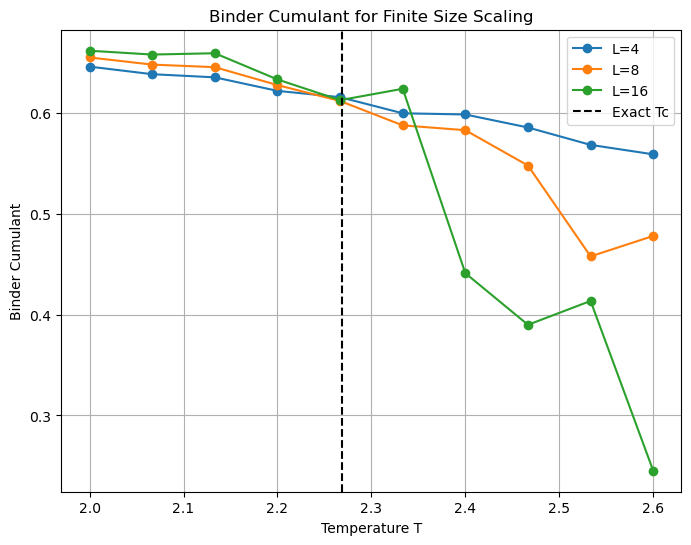

In [3]:
def run_simulation(L, temperatures, n_steps=2000, n_burnin=500):
    results = []
    for T in temperatures:
        model = IsingModel(L, T)
        # 焼きなまし（平衡状態へ）
        for _ in range(n_burnin): model.mcs_step()
        
        ms = []
        for _ in range(n_steps):
            model.mcs_step()
            ms.append(model.get_magnetization())
        
        ms = np.array(ms)
        m2 = np.mean(ms**2)
        m4 = np.mean(ms**4)
        binder = 1 - m4 / (3 * m2**2)
        results.append(binder)
    return results

Ls = [4, 8, 16]
temps = np.linspace(2.0, 2.6, 10)
binder_data = {}

for L in Ls:
    print(f"Simulating L={L}...")
    binder_data[L] = run_simulation(L, temps)

plt.figure(figsize=(8, 6))
for L in Ls:
    plt.plot(temps, binder_data[L], 'o-', label=f'L={L}')
plt.axvline(x=2.269, color='k', linestyle='--', label='Exact Tc')
plt.xlabel('Temperature T')
plt.ylabel('Binder Cumulant')
plt.legend()
plt.title('Binder Cumulant for Finite Size Scaling')
plt.grid(True)
plt.show()